# AthNLP 2025 - Lab 6: LLMs with tools
(This lab is heavily based on the respective tutorials about `smolagents` from the HF hub; check the links below.)

For more thorough explanations on tool calling you can check OpenAI's [function calling documentation](https://platform.openai.com/docs/guides/function-calling)

## Install dependencies

In [ ]:
!pip install -q -U smolagents[toolkit]
!pip install -q -U datasets
!pip install -q bitsandbytes
!pip install fast-flights

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.4/145.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 87.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 50.5 MB/s eta 0:00:00


## Agents
An agent is a system that leverages an AI model to interact with its environment in order to achieve a user-defined objective. It combines reasoning, planning, and the execution of actions (often via external tools) to fulfill tasks. In short, an agent is a system that uses an AI Model (typically an LLM) as its core reasoning engine, to:

*   **Understand natural language:** Interpret and respond to human instructions in a meaningful way.
*   **Reason and plan:** Analyze information, make decisions, and devise strategies to solve problems.
*   **Interact with its environment:** Gather information, take actions, and observe the results of those actions.

In a multi-step agent, at each step, the LLM can write an action, in the form of some calls to external tools. A common format (used by Anthropic, OpenAI, and many others) for writing these actions is "a JSON of tools names and arguments to use, which you then parse to know which tool to execute and with which arguments".

Multiple research papers have shown that having the tool calling LLMs in code is much better, see [this survey](https://openreview.net/forum?id=8dmNOD9hbq) from ICLR 2024 for more information. The reason for this is simply that we crafted our code languages specifically to be the best possible way to express actions performed by a computer.

### Levels of agency

As we read in the HF agents documentation, which you can check [here](https://huggingface.co/docs/smolagents/en/conceptual_guides/intro_agents), any system leveraging LLMs will integrate the LLM outputs into code. The influence of the LLM’s input on the code workflow is the level of agency of LLMs in the system. Note that with this definition, “agent” is not a discrete, 0 or 1 definition: instead, “agency” evolves on a continuous spectrum, as you give more or less power to the LLM on your workflow.

See in the table below how agency can vary across systems:

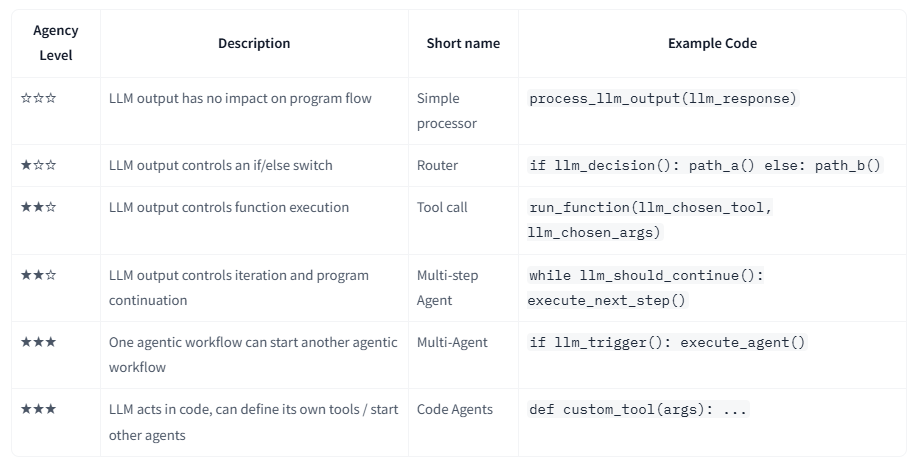

## Problem 1: Math equations solving using tools and code
In this part, you’ll create your very first Agent capable of performing actions such as code generation and execution, as well as mathematic operations through a python calculator to solve similar problems to those presented in Lab 5. To make this Agent, we’re going to use **smolagents**, a library that provides a framework for developing your agents with ease.

In short, smolagents is a library that focuses on codeAgent, a kind of agent that performs “Actions” through code blocks, and then “Observes” results by executing the code. This lightweight library is designed for simplicity, but it abstracts away much of the complexity of building an Agent, allowing you to focus on designing your agent’s behavior. It supports any LLM, either a local `transformers` or `ollama` model, one of [many providers on the Hub](https://huggingface.co/blog/inference-providers), or any model from OpenAI, Anthropic and many others via their [LiteLLM integration](https://www.litellm.ai/). For details, you can check this [blog post](https://huggingface.co/blog/smolagents) or the [library’s repo](https://github.com/huggingface/smolagents) in GitHub.



# Tool calling agents

A tool-calling agent interacts with the world by invoking predefined functions (also called “tools”) through structured inputs and outputs, often in a JSON-like format. This makes them predictable and easy to integrate with APIs, since the agent only needs to decide which tool to call and how to fill in its arguments. However, this structure can also become restrictive: nesting calls, managing complex intermediate objects, or composing multiple actions together can get cumbersome.

### Load the agent

We can use a tool-calling agent `ToolCallingAgent` which interacts with the world by invoking predefined functions (or “tools”) through structured inputs and outputs, often in a JSON-like format. This makes them predictable and easy to integrate with APIs, since the agent only needs to decide which tool to call and how to fill in its arguments. However, this structure can also become restrictive: nesting calls, managing complex intermediate objects, or composing multiple actions together can get cumbersome.

We can also use a `CodeAgent`, which is capable of writing and executing python coder. The figure below, taken from [Executable Code Actions Elicit Better LLM Agents](https://arxiv.org/abs/2402.01030), illustrates some advantages of writing actions in code. Writing actions in code rather than JSON-like snippets provides better:

*   **Composability:** could you nest JSON actions within each other, or define a set of JSON actions to re-use later, the same way you could just define a python function?
*   **Object management:** how do you store the output of an action like generate_image in JSON?
*   **Generality:** code is built to express simply anything you can have a computer do.
*   **Representation in LLM training data:** plenty of quality code actions is already included in LLMs’ training data which means they’re already trained for this!

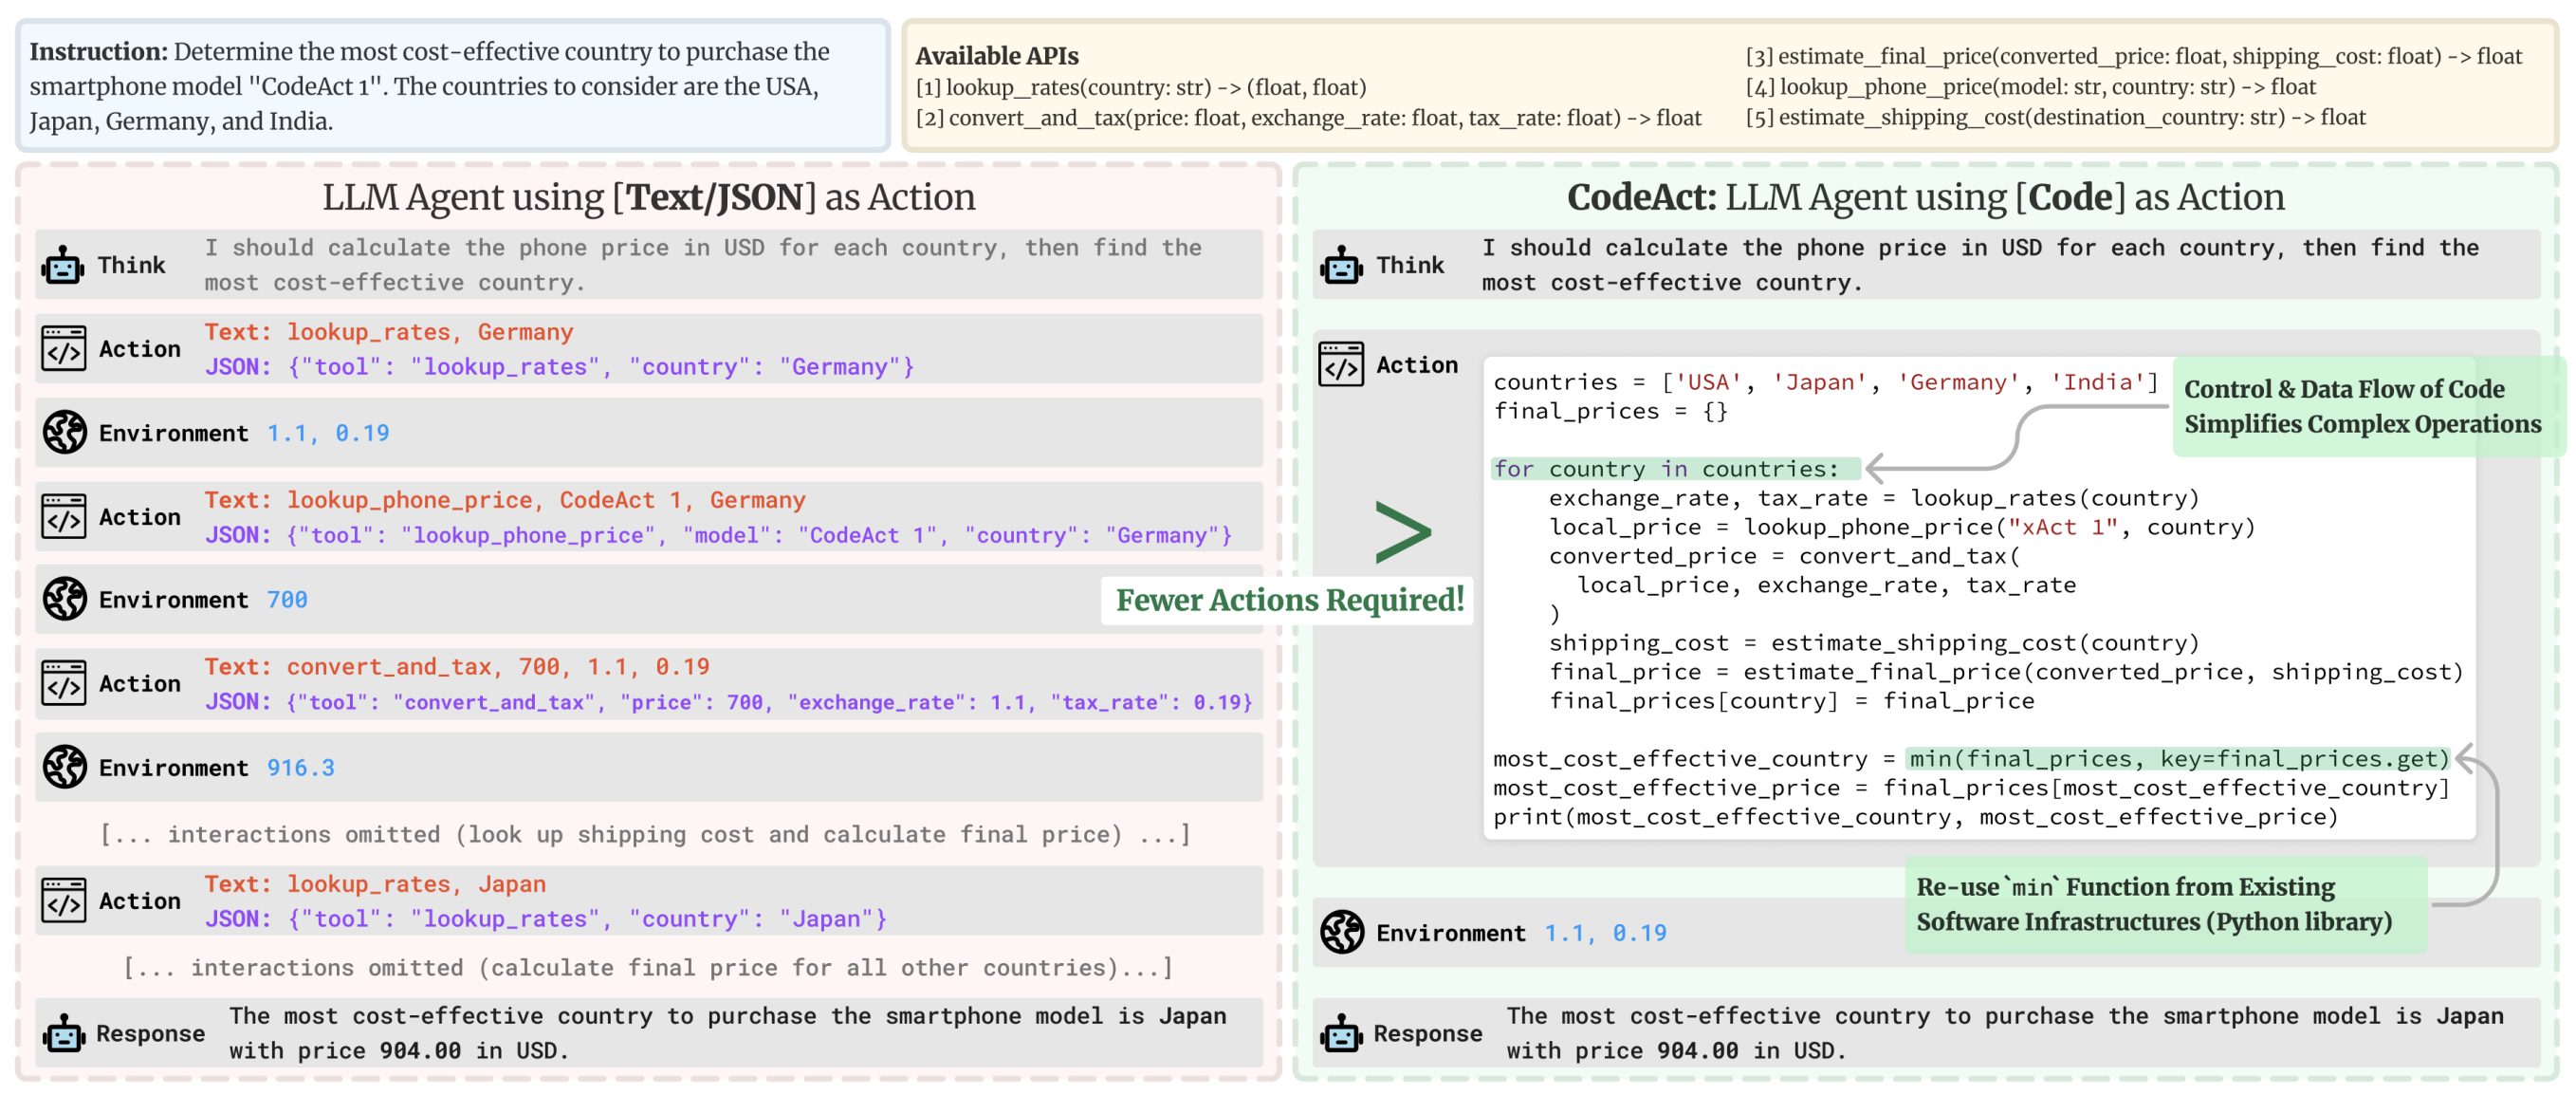

First we define the tool which will be used by the agent

In [ ]:
from smolagents import tool

@tool
def calculator(expr: str) -> float:
    """
    Evaluate a basic arithmetic expression.

    Args:
        expr: The math expression to evaluate, such as "2 + 3 * (4 / 2)".
    """
    return eval(expr, {"__builtins__": None}, {})

In [ ]:
calculator("2+3")

5

First we will create a ToolCallingAgent and inspect it's system prompt

In [ ]:
import transformers
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
from smolagents import CodeAgent, ToolCallingAgent, TransformersModel

model = TransformersModel(model_id="unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit")
tools = [calculator]

tool_agent = ToolCallingAgent(tools=tools, model=model, max_steps=6, stream_outputs=True)

# Inspect the system prompt
print(tool_agent.memory.system_prompt.system_prompt)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

You are an expert assistant who can solve any task using tool calls. You will be given a task to solve as best you can.
To do so, you have been given access to some tools.

The tool call you write is an action: after the tool is executed, you will get the result of the tool call as an "observation".
This Action/Observation can repeat N times, you should take several steps when needed.

You can use the result of the previous action as input for the next action.
The observation will always be a string: it can represent a file, like "image_1.jpg".
Then you can use it as input for the next action. You can do it for instance as follows:

Observation: "image_1.jpg"

Action:
{
  "name": "image_transformer",
  "arguments": {"image": "image_1.jpg"}
}

To provide the final answer to the task, use an action blob with "name": "final_answer" tool. It is the only way to complete the task, else you will be stuck on a loop. So your final output should look like this:
Action:
{
  "name": "final_answer"

In [ ]:
# Example GSM8K-style questions
questions = [
    "John has 3 boxes with 4 chocolates each. How many chocolates in total?",
    "A train travels 60 miles in 1.5 hours. What is its average speed?"
]

for q in questions:
    print("Q:", q)
    print("->", tool_agent.run(q))
    print("-" * 60)

Q: John has 3 boxes with 4 chocolates each. How many chocolates in total?


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ John has 3 boxes with 4 chocolates each. How many chocolates in total?                                          │
│                                                                                                                 │
╰─ TransformersModel - unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit ───────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output()

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'calculator' with arguments: {'expr': '3 * 4'}                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ Calling tool: 'final_answer' with arguments: {'answer': '40.0'}                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Observations: 40.0

Final answer: 40.0

[Step 2: Duration 8.14 seconds| Input tokens: 1,917 | Output tokens: 56]

-> 40.0
------------------------------------------------------------


Then we will create a CodeAgent and inspect it's system prompt

In [ ]:
import transformers
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM
from smolagents import CodeAgent, ToolCallingAgent, TransformersModel

tools = [calculator]

code_agent = CodeAgent(tools=tools, model=model, max_steps=6, stream_outputs=True)

# Inspect the system prompt
print(code_agent.memory.system_prompt.system_prompt)

You are an expert assistant who can solve any task using code blobs. You will be given a task to solve as best you can.
To do so, you have been given access to a list of tools: these tools are basically Python functions which you can call with code.
To solve the task, you must plan forward to proceed in a series of steps, in a cycle of Thought, Code, and Observation sequences.

At each step, in the 'Thought:' sequence, you should first explain your reasoning towards solving the task and the tools that you want to use.
Then in the Code sequence you should write the code in simple Python. The code sequence must be opened with '<code>', and closed with '</code>'.
During each intermediate step, you can use 'print()' to save whatever important information you will then need.
These print outputs will then appear in the 'Observation:' field, which will be available as input for the next step.
In the end you have to return a final answer using the `final_answer` tool.

Here are a few examples 

In [ ]:
# Example GSM8K-style questions
questions = [
    "John has 3 boxes with 4 chocolates each. How many chocolates in total?",
    "A train travels 60 miles in 1.5 hours. What is its average speed?"
]

for q in questions:
    print("Q:", q)
    print("->", code_agent.run(q))
    print("-" * 60)

Q: John has 3 boxes with 4 chocolates each. How many chocolates in total?


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ John has 3 boxes with 4 chocolates each. How many chocolates in total?                                          │
│                                                                                                                 │
╰─ TransformersModel - unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit ───────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output()

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  total_chocolates = calculator("3 * 4")                                                                           
  final_answer(total_chocolates)                                                                                   
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

...

Output()

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  average_speed = calculator("60 / 1.5")                                                                           
  final_answer(average_speed)                                                                                      
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: 40.0

[Step 1: Duration 24.93 seconds| Input tokens: 1,984 | Output tokens: 118]

-> 40.0
------------------------------------------------------------


**Pause and reflect:** Inspect the different system prompts of these agents and also their different outputs. What do you notice?

### Load the dataset

The GSM8K dataset (short for Grade School Math 8K) is a high-quality benchmark dataset designed to evaluate the mathematical reasoning capabilities of language models. It was introduced by OpenAI in the paper [Training Verifiers to Solve Math Word Problems](https://arxiv.org/abs/2110.14168) and contains 8,500 high-quality, human-annotated grade school-level math word problems.

Each problem includes:
*   a **question** (math problem written in natural language)
*   a **step-by-step rationale** (the solution written in full English prose)
*   a **final answer** (number)

The rationales (explanations) are separated from final answers using "\n####".

In [ ]:
from datasets import load_dataset

math_data = load_dataset("openai/gsm8k", "main")

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

We can look for example at how the question and answer are structured for item 5:

In [ ]:
['QUESTION: ' + math_data['test']['question'][5], 'ANSWER: ' + math_data['test']['answer'][5]]

['QUESTION: Kylar went to the store to buy glasses for his new apartment. One glass costs $5, but every second glass costs only 60% of the price. Kylar wants to buy 16 glasses. How much does he need to pay for them?',
 'ANSWER: The discount price of one glass is 60/100 * 5 = $<<60/100*5=3>>3.\nIf every second glass is cheaper, that means Kylar is going to buy 16 / 2 = <<16/2=8>>8 cheaper glasses.\nSo for the cheaper glasses, Kylar is going to pay 8 * 3 = $<<8*3=24>>24.\nAnd for the regular-priced glasses, Kylar will pay 8 * 5 = $<<8*5=40>>40.\nSo in total Kylar needs to pay 24 + 40 = $<<24+40=64>>64 for the glasses he wants to buy.\n#### 64']

Let's gather all question-answer pairs in a list for easier manipulation.

In [ ]:
contexts = [[math_data['test']['question'][i], math_data['test']['answer'][i]]
            for i in range(len(math_data['test']['question']))]

### Run the model on the GMS8K data
Let's ask the LLM to answer more questions from the test split of the dataset and again observe the answers:

In [ ]:
import re
from tqdm import tqdm

NUM_TEST_EXAMPLES = 10

answers = []
for context in tqdm(contexts[0:NUM_TEST_EXAMPLES]):
    print("Q:", context)

    agent_execution = code_agent.run(context[0])
    print("->", agent_execution)
    print("-" * 60)

    answers.append(re.sub("\s+", " ", str(agent_execution)))

print("\n".join(answers))

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-13329766.py:14: SyntaxWarning: invalid escape sequence '\s'
  answers.append(re.sub("\s+", " ", str(agent_execution)))
  0%|          | 0/10 [00:00<?, ?it/s]

Q: ["Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?", 'Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.\nShe makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.\n#### 18']


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends │
│ every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much   │
│ in dollars does she make every day at the farmers' market?                                                      │
│                                                                                                                 │
╰─ TransformersModel - unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit ───────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output()

...

Execution logs:
Regular earnings for the first 40 hours: 400
Overtime earnings for the remaining 5 hours: 60.0
Total earnings for the week: 460.0

Final answer: 460.0

[Step 1: Duration 37.38 seconds| Input tokens: 2,022 | Output tokens: 211]

100%|██████████| 10/10 [06:22<00:00, 38.29s/it]

-> 460.0
------------------------------------------------------------
18
3.0
70000.0
540
20
64.0
260
120
45.0
460.0


We can evaluate the model by computing accuracy. The model provides a result (numerical answer) so we will either get the value (if the answer comprises of only an integer of floating point number) or search for the last integer in its generated answers and store it as the answer. Then we will compute how many times that is equal to the correct answer, which is separated from the reasoning behind it by "\n####", as we've already seen.

In [ ]:
def find_last_integer(s):
    # Find all integer-like patterns (including negative numbers)
    numbers = re.findall(r'-?\d+', s)

    if numbers:
        # Return the last one as an integer
        return int(numbers[-1])

    # Return None if no integer is found
    return None

def evaluate_accuracy(data, llm_answers):
  accuracy = 0.0
  for i in range(len(data)):
    correct_answer = int(data[i][1].split("\n####")[1].strip())
    try:
      llm_answer = int(float(llm_answers[i]))
    except:
      llm_answer = find_last_integer(llm_answers[i])
    if correct_answer == llm_answer:
      accuracy += 1/len(data)
  return accuracy

llama_accuracy = evaluate_accuracy(contexts[0:NUM_TEST_EXAMPLES], answers)
print("LlaMA 3.2 agentic performance (in terms of accuracy):", llama_accuracy)

LlaMA 3.2 agentic performance (in terms of accuracy): 0.8999999999999999


**Pause and reflect:** The performance is the same with what we obtained using few-shot examples (in the first 10 examples) in [Lab 5](https://colab.research.google.com/drive/1ZcCv4SctvIostcsHRvSa4mZZ8TKZkhFp?usp=sharing). 🙂 What can we do to make it better?

* Try to enter different instructions when prompting the LLM apart from the questions and see what it gets to produce. You can change the system prompt of the LLM as we have discussed. What happens when you prompt the model to answer directly v.s. to think step-by-step (this is called chain-of-thought thinking as you already know).

* Observe the generated chains-of-thought. Do you spot any particular prolems you should let the system know about? Try to enter different prompts to help the model correct its mistakes and see what it gets to produce. Don't forget to encourage it to "think step-by-step" in the system instructions, it seems to be a great deal after all. 😉

* Try adding some training examples to help the LLM reason correctly. This is called few-shot inference, with these demonstrators the performance ramped up to 79%, remember from the previous lab? 🤔 Try to pick demonstrators in a clever way, not randomly, to find the optimal examples for each of the test questions.

### *Optional:* Trying out different prompts with the appropriate tools
The agent’s system prompt is stored in a separate `prompts.yaml` file. This file contains predefined instructions that guide the agent’s behavior. Storing prompts in a YAML file allows for easy customization and reuse across different agents or use cases. You can check [this example](https://huggingface.co/spaces/agents-course/First_agent_template/blob/main/prompts.yaml) of an agent's prompt to get some ideas and design your own.

In [ ]:
#@title Run the following cell if you need to clean up any memory.
import gc, sys

for name in ["tool_agent", "code_agent", "agent", "model", "tokenizer", "gen_pipeline"]:
    if name in globals():
        try:
            del globals()[name]
        except Exception:
            pass

gc.collect()

try:
    import torch
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        print("CUDA cleared.")
        print(f"Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB | Reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB")
    else:
        print("CUDA not available.")
except Exception as e:
    print("Torch not available or error during CUDA clear:", e)

CUDA cleared.
Allocated: 0.01 GB | Reserved: 7.22 GB


## Problem 2: Real-time Flight Finder with Tools and an Agent

In this part, we will evolve from “reasoning only” to a tool-using Agent that returns real flight options you can click and book. We will use smolagents CodeAgent plus a lightweight flight search wrapper (based on Google Flights scraping via fast_flights)—no API keys required.

### Step 1: Use the LLM without any tools

#### Load the model

Loading models from the Hugging Face Hub typically involves using the 🤗 [Transformers library](https://huggingface.co/docs/transformers/en/index), which allows easy access to pre-trained models for tasks like text classification, translation, summarization, and more. You typically need two components:
*   the **model** (e.g., Meta-Llama-3.1, mistral-7b-instruct, gemma-2-27b; check more examples below)
*   the **tokenizer** (for preprocessing text; check [Lab 0](https://github.com/athnlp/athnlp-labs-2025) for more information)

In [ ]:
import torch
import transformers
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# More models at https://huggingface.co/unsloth
# You can play around with more models of a similar size to compare their results.
# One suggestion is unsloth/Llama-3.2-3B-Instruct-bnb-4bit

model = AutoModelForCausalLM.from_pretrained(
    "unsloth/Qwen2.5-3B-Instruct-bnb-4bit",
    device_map=device,
)

tokenizer = AutoTokenizer.from_pretrained("unsloth/Qwen2.5-3B-Instruct-bnb-4bit")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

We can create a Hugging Face **text generation pipeline** for faster inference. Pipelines are simple and optimized inference class for many machine learning tasks like text generation, image segmentation, automatic speech recognition, document question answering, and more. You can find tutorials about pipelines [here](https://huggingface.co/docs/transformers/en/pipeline_tutorial).

In [ ]:
gen_pipeline = transformers.pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device_map=device,
)

Device set to use cuda:0


Let's define a function to generate an answer. An important concept introduced at this stage is the incorporation of Padding ([PAD]), Beginning of Sequence ([BOS]), and End of Sequence ([EOS]) tokens, which are fundamental in structuring the model’s interpretation and generation of text sequences. Each of these tokens is typically assigned a unique identifier within the model's vocabulary (e.g., 0 or another reserved index, which is obtained by ...).

For more information please check again [Lab 5](https://colab.research.google.com/drive/1ZcCv4SctvIostcsHRvSa4mZZ8TKZkhFp?usp=sharing).

In [ ]:
def answer(question, num_beams=1):
    response = gen_pipeline(
        question,
        do_sample=True,
        temperature=0.6,
        num_beams=num_beams,
        max_new_tokens=1500,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id,
        truncation=True,
    )

    return response[0]['generated_text']

In [ ]:
user_goal = """
Find flight options from Athens to London leaving at 2025-12-15.
Prefer the cheapest option.
Send me the details of the best flight according to my criteria as well as the link so I can also schedule my trip.
The details need to contain the price, the departure time, the arrival time, the flight duration, the number of stops and the airline.
"""

ans = answer(user_goal)
print(ans)


Find flight options from Athens to London leaving at 2025-12-15.
Prefer the cheapest option.
Send me the details of the best flight according to my criteria as well as the link so I can also schedule my trip.
The details need to contain the price, the departure time, the arrival time, the flight duration, the number of stops and the airline.
To find the cheapest flight options from Athens to London on December 15, 2025, you can use a travel search engine or an airline website. Here’s how you can do it:

### Step-by-Step Guide

1. **Use a Travel Search Engine:**
   - Go to a travel search engine like Skyscanner, Momondo, or Google Flights.
   - Enter your origin (Athens) and destination (London).
   - Set the date to December 15, 2025.
   - Select "Cheapest" or "Lowest Price" as your preference.
   - Look for the cheapest flight that meets your criteria.

2. **Example Flight Details (Assuming Cheapest Option):**

   - **Airline:** British Airways
   - **Price:** £70 (Note: Prices can f

In [ ]:
#@title Run the following cell if you need to clean up any memory.
import gc, sys

for name in ["tool_agent", "code_agent", "agent", "model", "tokenizer", "gen_pipeline"]:
    if name in globals():
        try:
            del globals()[name]
        except Exception:
            pass

gc.collect()

try:
    import torch
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        print("CUDA cleared.")
        print(f"Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB | Reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB")
    else:
        print("CUDA not available.")
except Exception as e:
    print("Torch not available or error during CUDA clear:", e)

CUDA cleared.
Allocated: 2.42 GB | Reserved: 7.29 GB


## Pause and Reflect: The model hallucinates multiple things including

1.   Date/Time
2.   Flights
3.   Price

This happens because the LLM relies on it's parametric knowledge and has no access to the internet to search for flights.

We will solve these issues by granting the LLM access to various tools, including a flight search tool.

### Step 2: Search flights tool

####
We will be utilizing the tool provided by https://github.com/AWeirdDev/flights to find flight results from Google Flights.

Each flight result has information such as arrival time, departure time, price, etcetera. For more information, please check their GitHub repository.

It is also important to note in addition to the search tool, we need to add tools which grab the date and also tools which can help the LLM find the IATA codes of the airports in the cities we wish to travel to.

Note 1: IATA codes are three-letter codes which are used to identify airports, cities and major metropolitan areas for air travel purposes. In our use case, IATA codes are required because the flights API searches for flights between specific airports and not just cities.

Note 2: ISO date format is simply a standardized format for dates and uses the order YYYY-MM-DD

In [ ]:
from typing import List, Dict, Any
from datetime import date, datetime, timedelta
import re

from smolagents import tool
from fast_flights import FlightData, Passengers, create_filter, get_flights_from_filter

# IATA codes for a few cities (used when users type city names instead of airport codes)
IATA_BY_CITY = {
    "athens": ["ATH"],
    "thessaloniki": ["SKG"],
    "london": ["LHR","LGW","LTN","STN","LCY"],
    "paris": ["CDG","ORY","BVA"],
    "milan": ["MXP","LIN","BGY"],
    "rome": ["FCO", "CIA"],
}

# Multi-airport city codes (e.g., "LON") expanded to individual IATAs
CITY_CODE_EXPANSIONS = {
    "LON": ["LHR","LGW","LTN","STN","LCY"],
    "PAR": ["CDG","ORY","BVA"],
    "MIL": ["MXP","LIN","BGY"],
    "ROM": ["FCO","CIA"],
}

def _norm_city(s: str) -> str:
    """Normalize free-text city names like ' London ' -> 'london' (letters only)."""
    return re.sub(r"[^a-z]", "", s.lower())

def _expand_iatas(codes: List[str]) -> List[str]:
    """
    Expand user inputs (city names like 'London', multi-airport codes like 'LON',
    or single-airport codes like 'LHR') to a deduplicated list of airport IATAs.

    Args:
        codes: A list of user-provided origin/destination tokens. Each token can be
               a city name ('London'), a multi-airport city code ('LON'), or an
               airport IATA ('LHR').

    Returns:
        A list of unique 3-letter IATA airport codes (e.g., ['LHR','LGW']).
    """
    out = []
    for c in codes or []:
        cu = c.strip().upper()
        if cu in CITY_CODE_EXPANSIONS:
            out += CITY_CODE_EXPANSIONS[cu]
        else:
            cn = _norm_city(c)
            if cn in IATA_BY_CITY:
                out += IATA_BY_CITY[cn]
            elif len(cu) == 3 and cu.isalpha():
                # only treat unknown inputs as IATA if they look like a 3-letter code
                out.append(cu)
            # otherwise: skip unknown long tokens like "ROME"
    seen, dedup = set(), []
    for x in out:
        if x not in seen:
            seen.add(x); dedup.append(x)
    return dedup

def _parse_stops(v) -> int:
    """Cheap parser: 0/1/2 or strings like '1 stop' -> 1. Defaults to 0."""
    if isinstance(v, (int, float)):
        return int(v)
    m = re.search(r"\d+", str(v))
    return int(m.group(0)) if m else 0

@tool
def get_current_date_iso() -> str:
    """
    Return today's date in ISO format (YYYY-MM-DD).

    Returns:
        str: ISO date string for today's date, e.g. "2025-09-11".
    """
    return date.today().isoformat()

@tool
def search_flights(
    origin_iatas: List[str],
    dest_iatas: List[str],
    date_iso: str,
    max_stops: int = 2,
    adults: int = 1,
) -> List[Dict[str, Any]]:
    """
    Search flights for a given date and route. Returns raw fields so the LLM can decide
    how to present and rank them. The agent will compute dates like
    "tomorrow" directly in Python before calling this tool if needed.

    Args:
        origin_iatas: Origin(s) as city names ('London'), multi-airport codes ('LON'),
                      or airport codes ('ATH').
        dest_iatas:   Destination(s) in the same style as origin_iatas.
        date_iso:     Outbound date in 'YYYY-MM-DD'.
        max_stops:    Maximum allowed stops (0,1,2).
        adults:       Number of adult passengers.

    Returns:
        List[Dict[str, Any]]: A de-duplicated list of raw flight options. Each dict contains:

          - origin (str): 3-letter origin IATA used in the query (e.g., "ATH").
          - destination (str): 3-letter destination IATA (e.g., "LGW").
          - date (str): Travel date in ISO format "YYYY-MM-DD" (echoes `date_iso`).
          - depart_time (str): Raw departure string from the source.
          - arrive_time (str): Raw arrival string from the source.
          - airline (str): Carrier airline name as displayed.
          - price_text (str): Price exactly as shown by the source (may include currency
            symbols/codes and non-breaking spaces, e.g., "SGD 220"). May be empty if unavailable.
          - stops (int): Parsed integer number of stops (0 for direct).
          - duration (str): Raw duration text (e.g., "4 hr 5 min"), unparsed.
          - deep_link (str): Google Flights deep link (a `tfs=...` URL-safe payload).

        Notes:
          - No currency conversion is performed; use `price_text` as display-only.
          - Times are raw strings from the scraper and may include date parts or be empty.
          - Results are de-duplicated by (origin, destination, date, depart_time, arrive_time,
            airline, stops, duration) to reduce near-duplicates
    """
    results: List[Dict[str, Any]] = []
    origins = _expand_iatas(origin_iatas)[:2]   # small cap to keep queries light
    dests   = _expand_iatas(dest_iatas)[:6]
    if not origins or not dests:
        return results

    for o in origins:
        for d in dests:
            try:
                # Many of these arguments have been hardcoded. How can we use the LLM to book different kinds of flights for example a business class flight.
                flt = create_filter(
                    flight_data=[FlightData(date=date_iso, from_airport=o, to_airport=d, max_stops=max_stops)],
                    trip="one-way",
                    seat="economy",
                    passengers=Passengers(adults=adults, children=0, infants_in_seat=0, infants_on_lap=0),
                    max_stops=max_stops,
                )
                b64 = flt.as_b64().decode("utf-8")
                res = get_flights_from_filter(flt, mode="common")
            except Exception:
                continue

            deep_link = f"https://www.google.com/travel/flights?tfs={b64}"

            for f in getattr(res, "flights", []) or []:
                results.append({
                    "origin": o,
                    "destination": d,
                    "date": date_iso,
                    "depart_time": str(getattr(f, "departure", "") or ""),
                    "arrive_time": str(getattr(f, "arrival", "") or ""),
                    "airline": str(getattr(f, "name", "") or ""),
                    "price_text": str(getattr(f, "price", "") or ""),
                    "stops": _parse_stops(getattr(f, "stops", 0)),
                    "duration": str(getattr(f, "duration", "") or ""),
                    "deep_link": deep_link,
                })

    # Deduplicate
    seen, unique = set(), []
    for r in results:
        key = (
            r["origin"], r["destination"], r["date"],
            r["depart_time"], r["arrive_time"],
            r["airline"], r["stops"], r["duration"]
        )
        if key in seen:
            continue
        seen.add(key)
        unique.append(r)

    return unique[:10] # If there are multiple results per day we simply print the 10 first

Here's how the output of the tool looks like

In [ ]:
search_flights(["ATH"], ["LHR"], "2025-12-25")

[{'origin': 'ATH',
  'destination': 'LHR',
  'date': '2025-12-25',
  'depart_time': '4:10 PM on Thu, Dec 25',
  'arrive_time': '6:10 PM on Thu, Dec 25',
  'airline': 'British Airways',
  'price_text': 'NT$3309',
  'stops': 0,
  'duration': '4 hr',
  'deep_link': 'https://www.google.com/travel/flights?tfs=GhwSCjIwMjUtMTItMjUoAmoFEgNBVEhyBRIDTEhSQgEBSAGYAQI='},
 {'origin': 'ATH',
  'destination': 'LHR',
  'date': '2025-12-25',
  'depart_time': '7:50 PM on Thu, Dec 25',
  'arrive_time': '9:50 PM on Thu, Dec 25',
  'airline': 'British Airways',
  'price_text': 'NT$3309',
  'stops': 0,
  'duration': '4 hr',
  'deep_link': 'https://www.google.com/travel/flights?tfs=GhwSCjIwMjUtMTItMjUoAmoFEgNBVEhyBRIDTEhSQgEBSAGYAQI='},
 {'origin': 'ATH',
  'destination': 'LHR',
  'date': '2025-12-25',
  'depart_time': '7:10 PM on Thu, Dec 25',
  'arrive_time': '9:15 PM on Thu, Dec 25',
  'airline': 'Aegean',
  'price_text': 'NT$3894',
  'stops': 0,
  'duration': '4 hr 5 min',
  'deep_link': 'https://www.goo

Define the agent and equip it with the tools we defined earlier to search for flights.

In [ ]:
from smolagents import CodeAgent, TransformersModel

model = TransformersModel(model_id="unsloth/Qwen2.5-3B-Instruct-bnb-4bit", max_new_tokens=2048)

tools = [get_current_date_iso, search_flights]

code_agent = CodeAgent(tools=tools, model=model, max_steps=8, stream_outputs=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

In [ ]:
user_goal = """
Find flight options from Athens to London leaving at 2025-12-15.
Prefer the cheapest option.
Send me the details of the best flight according to my criteria as well as the link so I can also schedule my trip.
The details need to contain the price, the departure time, the arrival time, the flight duration, the number of stops and the airline.
"""

print(code_agent.run(user_goal))

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Find flight options from Athens to London leaving at 2025-12-15.                                                │
│ Prefer the cheapest option.                                                                                     │
│ Send me the details of the best flight according to my criteria as well as the link so I can also schedule my   │
│ trip.                                                                                                           │
│ The details need to contain the price, the departure time, the arrival time, the flight duration, the number of │
│ stops and the airline.                                                                                          │
│                                                                                                                 │
╰─ TransformersModel - unsloth/Qwen2.5-3B-Instruct-bnb-4bit ──────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Output()

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  flights = search_flights(                                                                                        
      origin_iatas=['ATH'],  # Athens (Athens International Airport)                                               
      dest_iatas=['LON'],  # London (London Heathrow Airport)                                                      
      date_iso='2025-12-15',                                                                                       
      max_stops=0,  # No stops allowed                                                                             
      adults=1  # Single passenger                                                                                 
  )                                                                                                                
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Out: [{'origin': 'ATH', 'destination': 'LHR', 'date': '2025-12-15', 'depart_time': '1:25 PM on Mon, Dec 15', 
'arrive_time': '3:30 PM on Mon, Dec 15', 'airline': 'Aegean', 'price_text': 'SGD\xa095', 'stops': 0, 'duration': '4
hr 5 min', 'deep_link': 
'https://www.google.com/travel/flights?tfs=GhwSCjIwMjUtMTItMTUoAGoFEgNBVEhyBRIDTEhSQgEBSAGYAQI='}, {'origin': 
'ATH', 'destination': 'LHR', 'date': '2025-12-15', 'depart_time': '7:10 PM on Mon, Dec 15', 'arrive_time': '9:15 PM
on Mon, Dec 15', 'airline': 'Aegean', 'price_text': 'SGD\xa095', 'stops': 0, 'duration': '4 hr 5 min', 'deep_link':
'https://www.google.com/travel/flights?tfs=GhwSCjIwMjUtMTItMTUoAGoFEgNBVEhyBRIDTEhSQgEBSAGYAQI='}, {'origin': 
'ATH', 'destination': 'LHR', 'date': '2025-12-15', 'depart_time': '2:25 PM on Mon, Dec 15', 'arrive_time': '4:35 PM
on Mon, Dec 15', 'airline': 'British Airways', 'price_text': 'SGD\xa0142', 'stops': 0, 'duration': '4 hr 10 min', 
'deep_link': 'https://www.google.com/travel/flights?tfs=GhwSCjIwMjUtMTItMTUoAGoFEgNBVEhyBRIDTEhSQgEBSAGYAQI='}, 
{'origin': 'ATH', 'destination': 'LHR', 'date': '2025-12-15', 'depart_time': '9:05 AM on Mon, Dec 15', 
'arrive_time': '11:10 AM on Mon, Dec 15', 'airline': 'Aegean', 'price_text': 'SGD\xa0128', 'stops': 0, 'duration': 
'4 hr 5 min', 'deep_link': 
'https://www.google.com/travel/flights?tfs=GhwSCjIwMjUtMTItMTUoAGoFEgNBVEhyBRIDTEhSQgEBSAGYAQI='}, {'origin': 
'ATH', 'destination': 'LHR', 'date': '2025-12-15', 'depart_time': '4:00 PM on Mon, Dec 15', 'arrive_time': '5:55 PM
on Mon, Dec 15', 'airline': 'Aegean', 'price_text': 'SGD\xa0128', 'stops': 0, 'duration': '3 hr 55 min', 
'deep_link': 'https://www.google.com/travel/flights?tfs=GhwSCjIwMjUtMTItMTUoAGoFEgNBVEhyBRIDTEhSQgEBSAGYAQI='}, 
{'origin': 'ATH', 'destination': 'LHR', 'date': '2025-12-15', 'depart_time': '7:45 AM on Mon, Dec 15', 
'arrive_time': '10:00 AM on Mon, Dec 15', 'airline': 'British Airways', 'price_text': 'SGD\xa0142', 'stops': 0, 
'duration': '4 hr 15 min', 'deep_link': 
'https://www.google.com/travel/flights?tfs=GhwSCjIwMjUtMTItMTUoAGoFEgNBVEhyBRIDTEhSQgEBSAGYAQI='}, {'origin': 
'ATH', 'destination': 'LHR', 'date': '2025-12-15', 'depart_time': '8:10 PM on Mon, Dec 15', 'arrive_time': '10:10 
PM on Mon, Dec 15', 'airline': 'British Airways', 'price_text': 'SGD\xa0142', 'stops': 0, 'duration': '4 hr', 
'deep_link': 'https://www.google.com/travel/flights?tfs=GhwSCjIwMjUtMTItMTUoAGoFEgNBVEhyBRIDTEhSQgEBSAGYAQI='}, 
{'origin': 'ATH', 'destination': 'LGW', 'date': '2025-12-15', 'depart_time': '10:55 PM on Mon, Dec 15', 
'arrive_time': '12:55 AM on Tue, Dec 16', 'airline': 'Wizz Air', 'price_text': 'SGD\xa046', 'stops': 0, 'duration':
'4 hr', 'deep_link': 
'https://www.google.com/travel/flights?tfs=GhwSCjIwMjUtMTItMTUoAGoFEgNBVEhyBRIDTEdXQgEBSAGYAQI='}, {'origin': 
'ATH', 'destination': 'LGW', 'date': '2025-12-15', 'depart_time': '10:25 AM on Mon, Dec 15', 'arrive_time': '12:25 
PM on Mon, Dec 15', 'airline': 'SKY express', 'price_text': 'SGD\xa051', 'stops': 0, 'duration': '4 hr', 
'deep_link': 'https://www.google.com/travel/flights?tfs=GhwSCjIwMjUtMTItMTUoAGoFEgNBVEhyBRIDTEdXQgEBSAGYAQI='}, 
{'origin': 'ATH', 'destination': 'LGW', 'date': '2025-12-15', 'depart_time': '1:55 PM on Mon, Dec 15', 
'arrive_time': '4:00 PM on Mon, Dec 15', 'airline': 'easyJet', 'price_text': 'SGD\xa060', 'stops': 0, 'duration': 
'4 hr 5 min', 'deep_link': 
'https://www.google.com/travel/flights?tfs=GhwSCjIwMjUtMTItMTUoAGoFEgNBVEhyBRIDTEdXQgEBSAGYAQI='}]

...

Out: Cheapest Flight Details:
Price: SGD 46
Departure Time: 10:55 PM on Monday, December 15
Arrival Time: 12:55 AM on Tuesday, December 16
Flight Duration: 4 hours
Number of Stops: 0
Airline: Wizz Air

[Step 8: Duration 72.44 seconds| Input tokens: 38,736 | Output tokens: 1,493]

Reached max steps.

[Step 9: Duration 34.72 seconds| Input tokens: 44,056 | Output tokens: 1,667]

Based on the flight options found, the best flight for your criteria is:

**Cheapest Flight Details:**
- **Price:** SGD 46
- **Departure Time:** 10:55 PM on Monday, December 15
- **Arrival Time:** 12:55 AM on Tuesday, December 16
- **Flight Duration:** 4 hours
- **Number of Stops:** 0
- **Airline:** Wizz Air

You can find more information about this flight [here](https://www.google.com/travel/flights?tfs=GhwSCjIwMjUtMTItMTUoAGoFEgNBVEhyBRIDTEdXQgEBSAGYAQI=).

Please make sure to check the actual flight schedule and book your ticket accordingly.


##Pause and Reflect:
We have selected specific airports, departure date and cheapest flight as our criteria. How can we change these?

**(OPTIONAL)** Rewrite the search_flights tool to allow the LLM to select more details about the flight such as the seating (business class, economy etc.) or any more you wish. You can also try to use the ToolCallingAgent instead of the CodeAgent and see how that performs

In [ ]:
from smolagents import CodeAgent, TransformersModel, tool
from fast_flights import FlightData, Passengers, create_filter, get_flights_from_filter

## TO DO

@tool
def search_flights(
    origin_iatas: List[str],
    dest_iatas: List[str],
    date_iso: str,
    max_stops: int = 2,
    adults: int = 1,
    # ADD MORE ARGUMENTS HERE
) -> List[Dict[str, Any]]:
# MAKE SURE TO ADD A DETAILED DOCSTRING
  raise NotImplementedError()

@tool
def get_current_date_iso() -> str:
    """
    Return today's date in ISO format (YYYY-MM-DD).

    Returns:
        str: ISO date string for today's date, e.g. "2025-09-11".
    """
    return date.today().isoformat()

model = TransformersModel(model_id="unsloth/Qwen2.5-3B-Instruct-bnb-4bit", max_new_tokens=2048)

tools = [get_current_date_iso, search_flights]

code_agent = CodeAgent(tools=tools, model=model, max_steps=8, stream_outputs=True)

# Include in here your request to the LLM and see how it performs
user_goal = """

"""

print(code_agent.run(user_goal))